In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from scipy.stats import binomtest, ttest_ind, chi2_contingency, chisquare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from pandas.api.types import CategoricalDtype

df = pd.read_csv("train_data.csv")
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
train_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
91348,108635,15606267,Wilson,622,France,Female,35.0,7,98640.74,2,1.0,1.0,110457.99,1
2636,147941,15644891,Pirozzi,752,France,Female,32.0,2,0.00,1,1.0,0.0,159843.24,0
117007,88744,15702464,Watson,710,France,Male,31.0,4,0.00,3,0.0,0.0,160548.66,1
100279,125789,15701605,L?,704,Germany,Male,46.0,4,138912.17,1,0.0,1.0,141804.78,1
34835,135997,15757577,Hs?,675,Germany,Female,51.0,8,143390.51,1,1.0,0.0,168034.90,1


Avant de commencer il faut s'assurer de voir si il n'y a pas de valeur manquante.

In [29]:
df.isnull().sum()

ID                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Il n'y a pas de valeur manquante. Passons à l'analyse de la target.

In [30]:
train_set["Exited"].value_counts()

Exited
0    90564
1    24299
Name: count, dtype: int64

On voit que les deux classes de la target sont assez désiquilibré et c'est pour cette raison qu'on utilisera la métrique f1_score. On va d'abords utiliser un modéle de régréssion logistique pour un premier modéle.

##I) Analyse fondamentale 

#I.1) Définition des variables

•   Customer ID : Un identifiant unique pour chaque client (discret). Inutile pour le modéle.

•   Surname : Le nom de famille du client (discret). Inutile pour le modéle.

•   Credit Score : Une valeur numérique représentant le score de crédit du client (continue)

•   Geography : Le pays où réside le client (France, Spain ou Germany) (discret)

•   Gender : Le genre du client (Male or Female) (discret)

•   Age : L’âge du client (C'est une variable discréte mais qu'on va traiter comme une variable continue)

•   Tenure : Le nombre d’années pendant lesquelles le client est avec la banque (discret)

•   Balance : Le solde du compte du client (continue)

•   NumOfProducts : Le nombre de produits bancaires utilisés par le client (par exemple, compte d’épargne, carte de crédit) (discret)

•   HasCrCard : Si le client possède une carte de crédit (1 = oui, 0 = non) (discret)

•   IsActiveMember : Si le client est un membre actif (1 = oui, 0 = non) (discret)

•   EstimatedSalary : Le salaire estimé du client (continue)

•   Exited : Si le client a résilié (1 = oui, 0 = non) (discret)

•   Pour la définition des lignes, c'est les clients de la banque.

#I.2) Analyse fondamentale

Dans cette analyse on va rechercher les différentes causes de résiliation bancaire.

1) Âge avancé du client (proche de la retraite) – Les clients d’âge mûr, notamment ceux approchant de la retraite (par ex. 51–60 ans), présentent les taux de résiliation les plus élevés [medium.com](https://medium.com/@zargi.teddy7/bank-customer-churn-prediction-using-random-forest-classifier-4353f3ac8270#:~:text=%2A%20Highest%20Churn%20Rate%3A%20Pre,41%E2%80%9350%20years%20old). Les analyses montrent qu’au-delà d’environ 40 ans, la propension à quitter la banque augmente de manière significative
[huggingface.co](https://huggingface.co/AnilKumarK2004/bank-customer-churn-prediction-gbclassifier#:~:text=Key%20insights%3A). Cela s’explique souvent par le fait que ces clients réorganisent leurs finances (transfert de l’épargne vers des comptes retraite, etc.) ou sont attirés par des offres concurrentes mieux adaptées à leur profil senior [medium.com](https://medium.com/@zargi.teddy7/bank-customer-churn-prediction-using-random-forest-classifier-4353f3ac8270#:~:text=%2A%20Highest%20Churn%20Rate%3A%20Pre,41%E2%80%9350%20years%20old).

2) Compte inactif (absence d’activité de la part du client) – Un manque d’activité sur le compte est l’une des causes les plus courantes de clôture. Statistiquement, les clients non actifs résilient beaucoup plus souvent leur compte (27 % de churn) comparé aux clients actifs (14 %) [huggingface.co](https://huggingface.co/AnilKumarK2004/bank-customer-churn-prediction-gbclassifier#:~:text=,than%20active%20members%20%2814). Du point de vue de la banque, un compte déclaré inactif sur une longue période peut entraîner une fermeture administrative conformément à la réglementation (par exemple aucun mouvement ni contact pendant 12 mois) [ar24.fr](https://www.ar24.fr/banque-finance/cloture-compte-banque-motifs-courants/#:~:text=1,depuis%20un%20certain%20temps).

3) Peu de produits bancaires détenus (un seul produit) – Les clients ne détenant qu’un seul produit bancaire auprès de la banque sont bien plus enclins à fermer leur compte. En effet, les taux de churn culminent chez les utilisateurs d’un seul produit (environ 27 % de résiliation) [huggingface.co](https://huggingface.co/AnilKumarK2004/bank-customer-churn-prediction-gbclassifier#:~:text=,respectively). Ce faible engagement se traduit par une moindre fidélisation : de façon générale, moins un client utilise de produits, plus il est susceptible de partir, tandis qu’une plus grande diversification des produits favorise la rétention [mdpi.com](https://www.mdpi.com/2079-9292/13/22/4527#:~:text=match%20at%20L1864%20SHAP%20values,engagement%20customers).

4) Faible score de crédit du client – Un score de crédit bas est associé à une probabilité accrue de résiliation. Les clients ayant un score ≤ 500 (profil financier fragile) présentent le taux de départ le plus élevé, possiblement parce qu’ils éprouvent des difficultés de paiement, ce qui engendre insatisfaction ou clôture forcée du compte [medium.com](https://medium.com/@zargi.teddy7/bank-customer-churn-prediction-using-random-forest-classifier-4353f3ac8270#:~:text=,financial%20products%20without%20extreme%20scrutiny). D’ailleurs, du point de vue de la banque, ce profil se traduit souvent par des incidents (par ex. découverts non-autorisés à répétition) pouvant conduire l’établissement à fermer le compte pour risque financier [ar24.fr](https://www.ar24.fr/banque-finance/cloture-compte-banque-motifs-courants/#:~:text=2.%20Des%20d%C3%A9couverts%20non,r%C3%A9p%C3%A9tition).

5) Solde de compte très élevé – Paradoxalement, disposer d’un solde important peut favoriser la résiliation. Les analyses signalent que les clients avec un solde nettement supérieur à la moyenne (par ex. > 100–200 K €) font partie des plus susceptibles de quitter la banque
[linkedin.com](https://www.linkedin.com/pulse/customer-churn-analysis-bank-abhijeet-shinde-rlylc#:~:text=In%20Summary%2C%20age%20group%20of,retention%20and%20reduce%20chrun%20rate). Ces clients fortunés peuvent en effet transférer leurs fonds vers de meilleurs placements ou diversifier leurs dépôts pour des raisons de garantie (plafond d’assurance dépôts), ce qui se traduit statistiquement par une probabilité de churn plus élevée pour les soldes élevés [huggingface.co](https://huggingface.co/AnilKumarK2004/bank-customer-churn-prediction-gbclassifier#:~:text=,Limited%20direct%20impact%20on%20churn).

6) Genre du client (clientèle féminine) – Le sexe du client apparaît comme un facteur corrélé à la résiliation : les femmes ont une tendance légèrement plus élevée à quitter la banque que les hommes. Dans le jeu de données, le taux de churn des clientes avoisine 25 %, contre 16 % pour les clients masculins [huggingface.co](https://huggingface.co/AnilKumarK2004/bank-customer-churn-prediction-gbclassifier#:~:text=,than%20active%20members%20%2814). Ceci suggère qu’il existe des différences comportementales ou des besoins spécifiques non couverts qui peuvent conduire une partie de la clientèle féminine à fermer davantage leurs comptes (même si le genre n’est pas en soi une cause directe, il reflète une disparité observée dans les départs).

7) Pays de résidence du client – La géographie influence également la résiliation, certains marchés nationaux connaissant plus de churn que d’autres. Par exemple, les clients résidant en Allemagne affichent un taux de clôture d’environ 32 %, nettement supérieur à la France (16 %) ou l’Espagne (17 %) [huggingface.co](https://huggingface.co/AnilKumarK2004/bank-customer-churn-prediction-gbclassifier#:~:text=,than%20active%20members%20%2814). Ces écarts laissent penser que des facteurs régionaux (concurrence bancaire locale, politiques tarifaires, satisfaction client variable selon le pays) peuvent pousser la banque ou le client à mettre fin à la relation plus fréquemment dans certaines zones géographiques.

8) Faible ancienneté (nouveau client) – L’ancienneté du client joue sur la probabilité de churn : les nouveaux clients (par ex. moins de 2 ans chez la banque) sont les plus susceptibles de partir prématurément [medium.com](https://medium.com/@zargi.teddy7/bank-customer-churn-prediction-using-random-forest-classifier-4353f3ac8270#:~:text=,stage%20customer%20service). En phase initiale, un client peut être déçu ou trouver une meilleure offre ailleurs, d’où un taux de résiliation élevé au début de la relation. À l’inverse, une fois le cap des 3–5 ans passé, les clients ont tendance à rester beaucoup plus fidèles sur le long terme [medium.com](https://medium.com/@zargi.teddy7/bank-customer-churn-prediction-using-random-forest-classifier-4353f3ac8270#:~:text=,term%20retention), et une grande ancienneté est généralement synonyme de stabilité (les clients de longue date sont moins enclins à partir).

9) Absence de carte de crédit détenue – Ne pas posséder de carte de crédit auprès de la banque est un indicateur mineur mais notable de churn. Les clients sans carte de crédit sont souvent moins engagés dans la banque et donc un peu plus susceptibles de la quitter (corrélativement, ceux qui ont une carte de crédit sont statistiquement un peu plus fidèles) [enjoyalgorithms.com](https://www.enjoyalgorithms.com/blog/customer-churn-prediction-using-ml/#:~:text=,with%20lower%20salaries%20are%20more)
. Cela dit, l’impact de ce facteur reste limité par rapport aux raisons majeures ci-dessus (la possession d’une carte n’a qu’une influence marginale sur la décision de rester ou partir) [huggingface.co](https://huggingface.co/AnilKumarK2004/bank-customer-churn-prediction-gbclassifier#:~:text=,than).

10) Salaire estimé faible – Le niveau de revenu du client peut légèrement influencer la résiliation du compte. Les personnes ayant un salaire plus modeste ont tendance à quitter plus facilement la banque que celles ayant un salaire élevé [enjoyalgorithms.com](https://www.enjoyalgorithms.com/blog/customer-churn-prediction-using-ml/#:~:text=bank.%20,than%20those%20with%20higher%20wages). Un revenu faible peut signifier moins d’avantages ou une plus grande sensibilité aux frais, pouvant pousser le client à changer de banque. Néanmoins, dans les analyses de churn, le salaire n’a montré qu’un effet direct limité par rapport à d’autres facteurs financiers plus déterminants [huggingface.co](https://huggingface.co/AnilKumarK2004/bank-customer-churn-prediction-gbclassifier#:~:text=Key%20insights%3A).

On va du coup premiérement analyser chaque raison avec nos donné avec la méthode OPEC et si jamais cela ne suffit pas on analysera plus en profondeur les donnés.

##II) Âge avancé du client (proche de la retraite)

#II.1) Objectif

L'objectif est de prouver qu'il y a bien une augmentation du taux de résiliation au delà des 40 ans et qu'il y a le taux de résiliation le plus élevé pour les clients qui s'approche de la retraite.

#II.2) Plan

1) Analyse univarié de l'âge pour visualiser la distribution.

2) Analyse de l'âge en fonction de la target.

#II.3) Execution

II.3.1) Analyse univarié

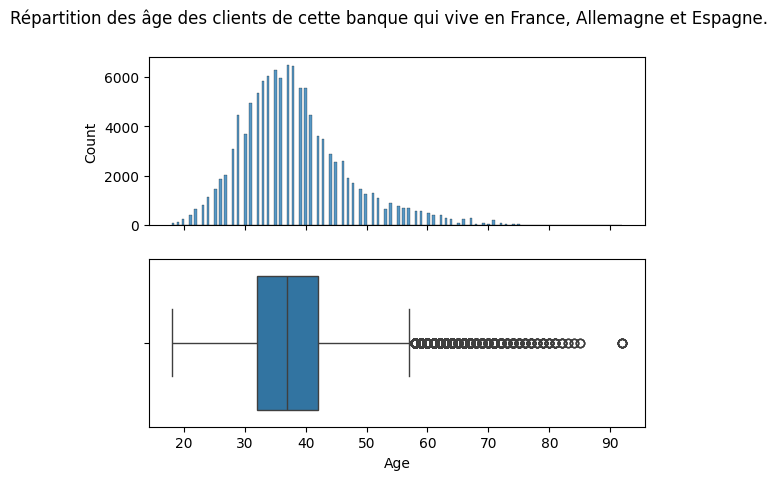

count    114863.000000
mean         38.143017
std           8.869733
min          18.000000
25%          32.000000
50%          37.000000
75%          42.000000
max          92.000000
Name: Age, dtype: float64

In [31]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle(
    "Répartition des âge des clients de cette banque qui vive en France, Allemagne et Espagne."
)
sns.histplot(data=train_set, x="Age", ax=ax[0])
sns.boxplot(data=train_set, x="Age", ax=ax[1])
plt.show()

train_set["Age"].describe()

La moyenne d'âge des clients de cette banque vivant en France, Allemagne et Espagne est de 38.143017 ans avec un écart-type de 8.869733 ans. Le client le plus jeune à 18 ans ce qui est logique car c'est l'âge minimum pour avoir un compte bancaire dans les trois pays. La personne la plus âgé à 92 ans qui est sûrement un retraité. On voit que sur l'histogramme la pluplart des clients ont entre 28 et 45 ans. On voit aussi qu'il y a des outliers à droite de la boxplot. Pour mieux voir l'évolution du taux de résiliation, on va étudier l'âge par tranche. On va d'abord créer une variable catégorielle avec l'âge et ensuite on passera à la deuxiéme étape.

In [40]:
condition_list = [
    train_set["Age"] < 30,
    (30 <= train_set["Age"]) & (train_set["Age"] < 40),
    (40 <= train_set["Age"]) & (train_set["Age"] < 50),
    (50 <= train_set["Age"]) & (train_set["Age"] < 60),
    (60 <= train_set["Age"]) & (train_set["Age"] < 70),
]

choice_list = [
    "Jeune adulte",
    "Trentenaire",
    "Quadragénaire",
    "Proche retraite",
    "Nouveau retraité",
]

train_set["Catégorie age"] = np.select(
    condition_list, choice_list, default="Ancien retraité"
)

train_set["Catégorie age"].value_counts()

Catégorie age
Trentenaire         56488
Quadragénaire       30235
Jeune adulte        16329
Proche retraite      8509
Nouveau retraité     2727
Ancien retraité       575
Name: count, dtype: int64

II.3.2) Analyse de l'âge en fonction de la target

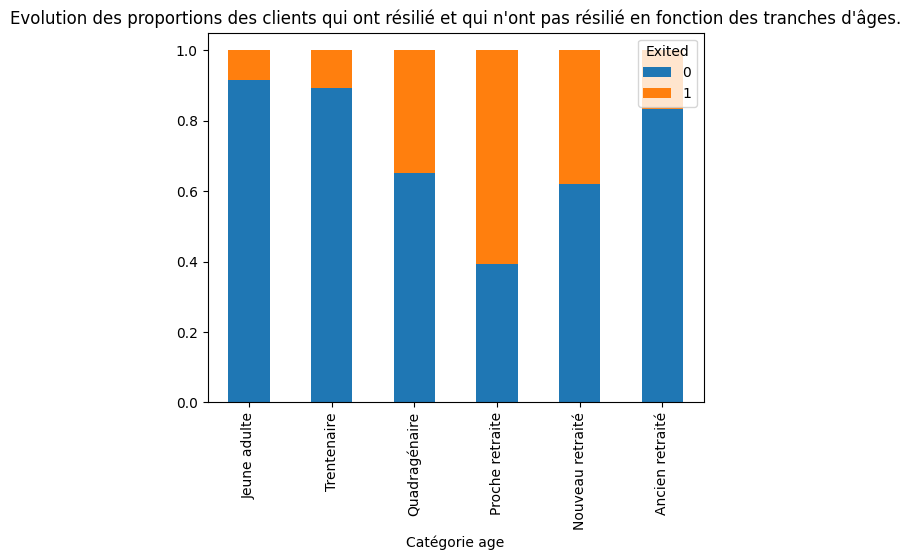

Exited,0,1
Catégorie age,,
Jeune adulte,0.915182,0.084818
Trentenaire,0.892650,0.107350
Quadragénaire,0.651067,0.348933
Proche retraite,0.392055,0.607945
Nouveau retraité,0.621562,0.378438
Ancien retraité,0.834783,0.165217


In [39]:
ordre = [
    "Jeune adulte",
    "Trentenaire",
    "Quadragénaire",
    "Proche retraite",
    "Nouveau retraité",
    "Ancien retraité",
]

idx_dtype = CategoricalDtype(categories=ordre, ordered=True)

pd.crosstab(
    train_set["Catégorie age"].astype(idx_dtype),
    train_set["Exited"],
    normalize="index",
).plot(kind="bar", stacked=True)
plt.title(
    "Evolution des proportions des clients qui ont résilié et qui n'ont pas résilié en fonction des tranches d'âges."
)
plt.show()

pd.crosstab(
    train_set["Catégorie age"].astype(idx_dtype),
    train_set["Exited"],
    normalize="index",
)

On voit bien que pour les clients qui sont proche de la retraite (entre 50 et 60 ans), le taux de résiliation est la plus forte avec un pourcentage de 60%. On a bien une augmentation du taux de résiliation entre les trentenairte et les quadragénaires jusqu'à 34%. Ensuite on a une diminution du taux de résiliation quand on passe des clients qui sont proche de la retraite et les nouveau retraité. Le taux résiliation pour les anciens retraité est trés bas. Maintenant il faut tester la relation entre les deux variables.

In [41]:
print("H0: Il n'y a pas de relation entre l'âge et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["Age"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre l'âge et la target.
Nous avons assez d'évidence pour rejeter H0.


On peut donc dire avec un seuil alpha de 2% qu'il y a bien une relation entre l'âge et la target.

II.3.2) Conclusion

On peut en conclure que les clients qui sont proche de la retraite résilie le plus. Les quadragénaires et les nouveau retraité ont un taux de résiliation aussi assez élevé. Cette variable est donc intéréssente pour le modéle.